<a href="https://colab.research.google.com/github/annabarsukovaca-stack/Machine-Learning-Practice/blob/main/metropolian_areas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#1. IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [7]:
# Upload Dataset

from google.colab import files

uploaded = files.upload()

Saving prices_busan.xlsx to prices_busan.xlsx
Saving prices_daegu.xlsx to prices_daegu (1).xlsx
Saving prices_daejeon.xlsx to prices_daejeon (1).xlsx
Saving prices_gwangju.xlsx to prices_gwangju (1).xlsx


In [8]:
# Load the 4 cities

busan = pd.read_excel("prices_busan.xlsx")
daegu = pd.read_excel("prices_daegu.xlsx")
gwangju = pd.read_excel("prices_gwangju.xlsx")
daejeon = pd.read_excel("prices_daejeon.xlsx")

print("Busan:", busan.shape)
print("Daegu:", daegu.shape)
print("Gwangju:", gwangju.shape)
print("Daejeon:", daejeon.shape)

Busan: (61152, 30)
Daegu: (32363, 30)
Gwangju: (25984, 30)
Daejeon: (21114, 30)


In [9]:
#data check

def check_data(data, city_name):

    print("=" * 60)
    print(city_name)
    print("=" * 60)

    print("\nShape:")
    print(data.shape)

    print("\nFirst 5 rows:")
    display(data.head())

    print("\nData types:")
    print(data.dtypes)

    print("\nMissing values:")
    print(data.isnull().sum())

    print("\nTotal missing values:")
    print(data.isnull().sum().sum())

    print("\nDuplicate rows:")
    print(data.duplicated().sum())


check_data(busan, "BUSAN")
check_data(daegu, "DAEGU")
check_data(gwangju, "GWANGJU")
check_data(daejeon, "DAEJEON")

BUSAN

Shape:
(61152, 30)

First 5 rows:


,Spring,Fall,Winter,Date of transaction,Longitude,Latitude,Crow-fly distance to nearest subway station,Size of unit,Condominium price,Floor,...,Network distance to nearest greenspace,Network distance to nearest waterfront,Number of bus stops,Population,Sex ratio,Medium age,Young population ratio,Old population ratio,Population density,Ratio of adults with higher degrees
0,0,0,1,201501,128.902065,35.083129,5644.141796,101.96,31500,12,...,3575.754902,451.974067,8,36682,99,36,24.276212,6.482744,2357.891374,44.918458
1,0,0,1,201501,128.902065,35.083129,5644.141796,84.97,27000,14,...,3575.754902,451.974067,8,36682,99,36,24.276212,6.482744,2357.891374,44.918458
2,0,0,1,201501,128.902065,35.083129,5644.141796,149.87,45700,15,...,3575.754902,451.974067,8,36682,99,36,24.276212,6.482744,2357.891374,44.918458
3,0,0,1,201501,128.902065,35.083129,5644.141796,84.97,27800,13,...,3575.754902,451.974067,8,36682,99,36,24.276212,6.482744,2357.891374,44.918458
4,0,0,1,201501,128.902065,35.083129,5644.141796,84.99,28500,9,...,3575.754902,451.974067,8,36682,99,36,24.276212,6.482744,2357.891374,44.918458



Data types:
Spring                                           int64
Fall                                             int64
Winter                                           int64
Date of transaction                              int64
Longitude                                      float64
Latitude                                       float64
Crow-fly distance to nearest subway station    float64
Size of unit                                   float64
Condominium price                                int64
Floor                                            int64
Construction year                                int64
Network distance to nearest subway station     float64
Number of households                             int64
Number of condominium buildings                  int64
Highest floor                                    int64
Parking space per household                    float64
Heating type                                     int64
Number of top university entrants                int

,Spring,Fall,Winter,Date of transaction,Longitude,Latitude,Crow-fly distance to nearest subway station,Size of unit,Condominium price,Floor,...,Network distance to nearest greenspace,Network distance to nearest waterfront,Number of bus stops,Population,Sex ratio,Medium age,Young population ratio,Old population ratio,Population density,Ratio of adults with higher degrees
0,0,0,1,201501,128.570034,35.840219,510.352805,59.80,15000,8,...,310.951163,847.854754,9,10016,96,45,8.456470,17.801518,20148.000000,25.400807
1,0,0,1,201501,128.577144,35.847898,1000.061743,71.28,11600,5,...,726.327103,1501.481208,4,12028,96,48,8.072830,18.365481,17050.704225,18.350366
2,0,0,1,201501,128.567621,35.844357,878.381171,60.88,11000,5,...,116.849499,567.954208,4,12028,96,48,8.072830,18.365481,17050.704225,18.350366
3,0,0,1,201501,128.567621,35.844357,878.381171,60.73,10500,5,...,116.849499,567.954208,4,12028,96,48,8.072830,18.365481,17050.704225,18.350366
4,0,0,1,201501,128.589685,35.845201,404.741090,83.16,14000,5,...,1023.057433,1525.911649,5,8956,97,44,7.101385,17.831621,9872.826087,25.240385



Data types:
Spring                                           int64
Fall                                             int64
Winter                                           int64
Date of transaction                              int64
Longitude                                      float64
Latitude                                       float64
Crow-fly distance to nearest subway station    float64
Size of unit                                   float64
Condominium price                                int64
Floor                                            int64
Construction year                                int64
Network distance to nearest subway station     float64
Number of households                             int64
Number of condominium buildings                  int64
Highest floor                                    int64
Parking space per household                    float64
Heating type                                     int64
Number of top university entrants                int

,Spring,Fall,Winter,Date of transaction,Longitude,Latitude,Crow-fly distance to nearest subway station,Size of unit,Condominium price,Floor,...,Network distance to nearest greenspace,Network distance to nearest waterfront,Number of bus stops,Population,Sex ratio,Medium age,Young population ratio,Old population ratio,Population density,Ratio of adults with higher degrees
0,0,0,1,201501,126.791224,35.128078,148.326547,39.15,5750,3,...,1139.644292,686.042943,4,14118,103,38,17.785805,10.922227,3563.341646,26.113552
1,0,0,1,201501,126.791224,35.128078,148.326547,59.31,7600,1,...,1139.644292,686.042943,4,14118,103,38,17.785805,10.922227,3563.341646,26.113552
2,0,0,1,201501,126.795759,35.128768,533.046230,84.98,14400,9,...,1512.250624,1041.596110,2,14118,103,38,17.785805,10.922227,3563.341646,26.113552
3,0,0,1,201501,126.795759,35.128768,533.046230,84.98,15200,10,...,1512.250624,1041.596110,2,14118,103,38,17.785805,10.922227,3563.341646,26.113552
4,0,0,1,201501,126.798213,35.131044,590.178663,84.95,16400,8,...,1489.999929,1226.233192,2,14118,103,38,17.785805,10.922227,3563.341646,26.113552



Data types:
Spring                                           int64
Fall                                             int64
Winter                                           int64
Date of transaction                              int64
Longitude                                      float64
Latitude                                       float64
Crow-fly distance to nearest subway station    float64
Size of unit                                   float64
Condominium price                                int64
Floor                                            int64
Construction year                                int64
Network distance to nearest subway station     float64
Number of households                             int64
Number of condominium buildings                  int64
Highest floor                                    int64
Parking space per household                    float64
Heating type                                     int64
Number of top university entrants                int

,Spring,Fall,Winter,Date of transaction,Longitude,Latitude,Crow-fly distance to nearest subway station,Size of unit,Condominium price,Floor,...,Network distance to nearest greenspace,Network distance to nearest waterfront,Number of bus stops,Population,Sex ratio,Medium age,Young population ratio,Old population ratio,Population density,Ratio of adults with higher degrees
0,0,0,1,201501,127.418178,36.365414,3242.991914,56.26,5000,3,...,304.212680,1497.013049,9,8698,108,44,10.634629,15.210393,2858.227848,15.708221
1,0,0,1,201501,127.418240,36.366602,3309.025823,63.08,7250,1,...,388.901825,1380.695275,7,8698,108,44,10.634629,15.210393,2858.227848,15.708221
2,0,0,1,201501,127.413399,36.367394,2954.547286,49.00,4200,2,...,381.296247,1112.778380,4,8698,108,44,10.634629,15.210393,2858.227848,15.708221
3,0,0,1,201501,127.416908,36.363519,3030.157959,46.10,9000,11,...,136.434357,1300.727197,5,8698,108,44,10.634629,15.210393,2858.227848,15.708221
4,0,0,1,201501,127.416908,36.363519,3030.157959,35.88,6900,7,...,136.434357,1300.727197,5,8698,108,44,10.634629,15.210393,2858.227848,15.708221



Data types:
Spring                                           int64
Fall                                             int64
Winter                                           int64
Date of transaction                              int64
Longitude                                      float64
Latitude                                       float64
Crow-fly distance to nearest subway station    float64
Size of unit                                   float64
Condominium price                                int64
Floor                                            int64
Construction year                                int64
Network distance to nearest subway station     float64
Number of households                             int64
Number of condominium buildings                  int64
Highest floor                                    int64
Parking space per household                    float64
Heating type                                     int64
Number of top university entrants                int

to check how many observations and variables and if missing values, duplicate rows

In [10]:
#create month variable

for data in [busan, daegu, gwangju, daejeon]:

    data["Month"] = data["Date of transaction"] % 100

print("Month variable created.")

Month variable created.


LOG TRANSFORMATION

In [11]:
LOG_FEATURES = [
    "Network distance to nearest greenspace",
    "Network distance to nearest waterfront",
    "Network distance to nearest subway station"
]

Log-transformation of Condominium prices

In [12]:
#log transformation

LOG_FEATURES = [
    "Network distance to nearest greenspace",
    "Network distance to nearest waterfront",
    "Network distance to nearest subway station"
]

TARGET = "Condominium price"


def apply_log_transform(data):

    data = data.copy()

    for col in LOG_FEATURES:
        data[col] = np.log1p(data[col])

    data[TARGET] = np.log1p(data[TARGET])

    return data


busan_log = apply_log_transform(busan)
daegu_log = apply_log_transform(daegu)
gwangju_log = apply_log_transform(gwangju)
daejeon_log = apply_log_transform(daejeon)

print("Log transformation completed.")

Log transformation completed.


dummy variables:
Spring = 0 or 1
Fall   = 0 or 1
Winter = 0 or 1

In [13]:
#descriptive statistics

print("BUSAN")
display(busan_log.describe().T)

BUSAN


,count,mean,std,min,25%,50%,75%,max
Spring,61152.0,0.302312,0.459264,0.000000,0.000000,0.000000,1.000000,1.000000
Fall,61152.0,0.253352,0.434934,0.000000,0.000000,0.000000,1.000000,1.000000
Winter,61152.0,0.193959,0.395401,0.000000,0.000000,0.000000,0.000000,1.000000
Date of transaction,61152.0,201506.272894,3.289566,201501.000000,201503.000000,201506.000000,201509.000000,201512.000000
Longitude,61152.0,129.073772,0.069619,128.837694,129.017634,129.080072,129.118808,129.239438
Latitude,61152.0,35.174333,0.058341,35.048865,35.140153,35.172621,35.206303,35.338534
Crow-fly distance to nearest subway station,61152.0,1519.400950,1937.800116,9.537902,423.290862,762.653490,1705.518711,9918.979923
Size of unit,61152.0,79.465405,29.962432,14.740000,59.800000,82.520000,84.980000,250.850000
Condominium price,61152.0,9.966446,0.534976,6.593045,9.632400,9.980495,10.319596,12.847508
Floor,61152.0,10.510139,7.789410,-1.000000,4.000000,9.000000,15.000000,79.000000


In [14]:
print("DAEGU")
display(daegu_log.describe().T)

print("GWANGJU")
display(gwangju_log.describe().T)

print("DAEJEON")
display(daejeon_log.describe().T)

DAEGU


,count,mean,std,min,25%,50%,75%,max
Spring,32363.0,0.343695,0.474948,0.000000,0.000000,0.000000,1.000000,1.000000
Fall,32363.0,0.179372,0.383669,0.000000,0.000000,0.000000,0.000000,1.000000
Winter,32363.0,0.213268,0.409622,0.000000,0.000000,0.000000,0.000000,1.000000
Date of transaction,32363.0,201505.533634,3.101302,201501.000000,201503.000000,201505.000000,201508.000000,201512.000000
Longitude,32363.0,128.577657,0.065759,128.435187,128.533168,128.561658,128.622342,128.731487
Latitude,32363.0,35.859904,0.042312,35.692545,35.833521,35.856915,35.879039,35.953674
Crow-fly distance to nearest subway station,32363.0,1089.404999,1573.793474,4.887224,405.518937,655.738044,1145.426269,14224.913236
Size of unit,32363.0,79.714175,30.130863,12.650000,59.830000,83.470000,84.980000,250.910000
Condominium price,32363.0,10.035763,0.514796,7.783641,9.692828,10.034560,10.373522,12.245298
Floor,32363.0,8.908908,6.258638,1.000000,4.000000,8.000000,13.000000,56.000000


GWANGJU


,count,mean,std,min,25%,50%,75%,max
Spring,25984.0,0.294874,0.455995,0.000000,0.000000,0.000000,1.000000,1.000000
Fall,25984.0,0.239994,0.427088,0.000000,0.000000,0.000000,0.000000,1.000000
Winter,25984.0,0.268665,0.443274,0.000000,0.000000,0.000000,1.000000,1.000000
Date of transaction,25984.0,201505.966171,3.575195,201501.000000,201503.000000,201505.000000,201509.000000,201512.000000
Longitude,25984.0,126.869173,0.040730,126.772611,126.835948,126.874593,126.900052,126.945353
Latitude,25984.0,35.165574,0.031040,35.082597,35.135740,35.166927,35.188396,35.223864
Crow-fly distance to nearest subway station,25984.0,3320.783305,2251.945128,12.938932,1293.533191,3078.710722,4659.586199,9073.704351
Size of unit,25984.0,72.953346,24.643206,14.120000,59.760000,68.320000,84.920000,283.110000
Condominium price,25984.0,9.620838,0.484493,7.972811,9.259226,9.615872,9.937937,11.396403
Floor,25984.0,8.438462,5.349119,-1.000000,4.000000,8.000000,12.000000,28.000000


DAEJEON


,count,mean,std,min,25%,50%,75%,max
Spring,21114.0,0.278536,0.448289,0.000000,0.000000,0.000000,1.000000,1.000000
Fall,21114.0,0.254618,0.435656,0.000000,0.000000,0.000000,1.000000,1.000000
Winter,21114.0,0.235862,0.424547,0.000000,0.000000,0.000000,0.000000,1.000000
Date of transaction,21114.0,201506.393720,3.465031,201501.000000,201503.000000,201506.000000,201510.000000,201512.000000
Longitude,21114.0,127.390539,0.040281,127.301458,127.366970,127.391511,127.423424,127.469043
Latitude,21114.0,36.347280,0.035567,36.282179,36.322173,36.343097,36.363813,36.452678
Crow-fly distance to nearest subway station,21114.0,2500.487171,2425.516633,27.672234,732.564119,1403.277624,3886.115559,11807.338700
Size of unit,21114.0,75.310611,26.404323,12.010000,59.440000,83.940000,84.960000,260.950000
Condominium price,21114.0,9.755647,0.516277,7.601402,9.421492,9.815421,10.122663,11.951187
Floor,21114.0,8.668277,5.794319,1.000000,4.000000,8.000000,12.000000,50.000000


multicollinearity check

In [15]:
#multicollinearity check — VIF

def calculate_vif(data):

    X = data.drop(columns=[TARGET, "Date of transaction"])

    X = X.select_dtypes(include=np.number)

    vif = pd.DataFrame()
    vif["Feature"] = X.columns
    vif["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]

    return vif.sort_values("VIF", ascending=False)


vif_busan = calculate_vif(busan_log)

display(vif_busan)

,Feature,VIF
17,Network distance to the CBD,19.307691
16,Number of high schools,12.334931
5,Crow-fly distance to nearest subway station,9.687930
25,Old population ratio,8.272014
23,Medium age,7.420178
24,Young population ratio,7.043458
10,Number of households,4.797961
11,Number of condominium buildings,4.464880
27,Ratio of adults with higher degrees,3.748375
3,Longitude,3.325704


VIF ≈ 1       → little multicollinearity
VIF 1–5       → moderate/usually acceptable
VIF > 5       → potentially concerning
VIF > 10      → strong concern

prepare X and y

In [16]:
#create X and y

def prepare_X_y(data):

    X = data.drop(
        columns=["Condominium price", "Date of transaction"]
    )

    y = data["Condominium price"]

    return X, y


X_busan, y_busan = prepare_X_y(busan_log)
X_daegu, y_daegu = prepare_X_y(daegu_log)
X_gwangju, y_gwangju = prepare_X_y(gwangju_log)
X_daejeon, y_daejeon = prepare_X_y(daejeon_log)

print("Busan X:", X_busan.shape)
print("Busan y:", y_busan.shape)

Busan X: (61152, 29)
Busan y: (61152,)


X = predictors / information going into the model.
y = target / condominium price we want to predict.

In [17]:
#train / test split

def split_data(X, y):

    return train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )


X_train_busan, X_test_busan, y_train_busan, y_test_busan = split_data(
    X_busan, y_busan
)

X_train_daegu, X_test_daegu, y_train_daegu, y_test_daegu = split_data(
    X_daegu, y_daegu
)

X_train_gwangju, X_test_gwangju, y_train_gwangju, y_test_gwangju = split_data(
    X_gwangju, y_gwangju
)

X_train_daejeon, X_test_daejeon, y_train_daejeon, y_test_daejeon = split_data(
    X_daejeon, y_daejeon
)

print("Train/test split completed.")

Train/test split completed.


80% training
20% testing

normalize/scale using Min-Max scaling

In [18]:
#MIN-MAX NORMALIZATION

scaler_busan = MinMaxScaler()
scaler_daegu = MinMaxScaler()
scaler_gwangju = MinMaxScaler()
scaler_daejeon = MinMaxScaler()

X_train_busan_scaled = scaler_busan.fit_transform(X_train_busan)
X_test_busan_scaled = scaler_busan.transform(X_test_busan)

X_train_daegu_scaled = scaler_daegu.fit_transform(X_train_daegu)
X_test_daegu_scaled = scaler_daegu.transform(X_test_daegu)

X_train_gwangju_scaled = scaler_gwangju.fit_transform(X_train_gwangju)
X_test_gwangju_scaled = scaler_gwangju.transform(X_test_gwangju)

X_train_daejeon_scaled = scaler_daejeon.fit_transform(X_train_daejeon)
X_test_daejeon_scaled = scaler_daejeon.transform(X_test_daejeon)

print("Normalization completed.")

Normalization completed.


I don't fit the scaler on the test data.
That's because the test set must remain unseen during training. Scikit-learn's transformation workflow is designed around fitting transformations on training data and applying them to unseen data

OLS

In [19]:
#OLS — BUSAN

ols_busan = LinearRegression()

ols_busan.fit(
    X_train_busan_scaled,
    y_train_busan
)

ols_pred_busan = ols_busan.predict(
    X_test_busan_scaled
)

ols_r2_busan = r2_score(
    y_test_busan,
    ols_pred_busan
)

ols_rmse_busan = np.sqrt(
    mean_squared_error(
        y_test_busan,
        ols_pred_busan
    )
)

print("Busan OLS")
print("R²:", ols_r2_busan)
print("RMSE:", ols_rmse_busan)

Busan OLS
R²: 0.8393527908662705
RMSE: 0.21289838015514465


Random Forest

In [20]:
#RANDOM FOREST — BUSAN

rf_busan = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_busan.fit(
    X_train_busan_scaled,
    y_train_busan
)

rf_pred_busan = rf_busan.predict(
    X_test_busan_scaled
)

rf_r2_busan = r2_score(
    y_test_busan,
    rf_pred_busan
)

rf_rmse_busan = np.sqrt(
    mean_squared_error(
        y_test_busan,
        rf_pred_busan
    )
)

print("Busan Random Forest")
print("R²:", rf_r2_busan)
print("RMSE:", rf_rmse_busan)

Busan Random Forest
R²: 0.9797258107740517
RMSE: 0.07563233565398915


n_estimators=300 means:
Build 300 trees.

XGBoost = Extreme Gradient Boosting.
Instead of building many independent trees like Random Forest, XGBoost builds trees sequentially, with later trees trying to correct errors from earlier trees.
XGBRegressor is specifically the regression version of XGBoost

In [21]:
#XGBOOST — BUSAN

xgb_busan = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)

xgb_busan.fit(
    X_train_busan_scaled,
    y_train_busan
)

xgb_pred_busan = xgb_busan.predict(
    X_test_busan_scaled
)

xgb_r2_busan = r2_score(
    y_test_busan,
    xgb_pred_busan
)

xgb_rmse_busan = np.sqrt(
    mean_squared_error(
        y_test_busan,
        xgb_pred_busan
    )
)

print("Busan XGBoost")
print("R²:", xgb_r2_busan)
print("RMSE:", xgb_rmse_busan)

Busan XGBoost
R²: 0.9736914584262175
RMSE: 0.08615572696380949


XGBoost's n_estimators, max_depth, and learning_rate control the number/depth of trees and the boosting step size

In [22]:
#train ALL 3 models

def train_models(
    X_train,
    X_test,
    y_train,
    y_test,
    city_name
):

    # -------------------------
    # OLS
    # -------------------------

    ols = LinearRegression()

    ols.fit(
        X_train,
        y_train
    )

    ols_pred = ols.predict(X_test)

    ols_r2 = r2_score(
        y_test,
        ols_pred
    )

    ols_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            ols_pred
        )
    )


    # RANDOM FOREST


    rf = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(
        X_train,
        y_train
    )

    rf_pred = rf.predict(X_test)

    rf_r2 = r2_score(
        y_test,
        rf_pred
    )

    rf_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            rf_pred
        )
    )


    # XGBOOST


    xgb = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror",
        n_jobs=-1
    )

    xgb.fit(
        X_train,
        y_train
    )

    xgb_pred = xgb.predict(X_test)

    xgb_r2 = r2_score(
        y_test,
        xgb_pred
    )

    xgb_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            xgb_pred
        )
    )


    # RESULTS


    results = pd.DataFrame({
        "City": [city_name] * 3,
        "Model": [
            "OLS",
            "Random Forest",
            "XGBoost"
        ],
        "R²": [
            ols_r2,
            rf_r2,
            xgb_r2
        ],
        "RMSE": [
            ols_rmse,
            rf_rmse,
            xgb_rmse
        ]
    })

    return results, ols, rf, xgb

In [23]:
#TRAIN ALL CITIES

results_busan, ols_busan, rf_busan, xgb_busan = train_models(
    X_train_busan_scaled,
    X_test_busan_scaled,
    y_train_busan,
    y_test_busan,
    "Busan"
)

results_daegu, ols_daegu, rf_daegu, xgb_daegu = train_models(
    X_train_daegu_scaled,
    X_test_daegu_scaled,
    y_train_daegu,
    y_test_daegu,
    "Daegu"
)

results_gwangju, ols_gwangju, rf_gwangju, xgb_gwangju = train_models(
    X_train_gwangju_scaled,
    X_test_gwangju_scaled,
    y_train_gwangju,
    y_test_gwangju,
    "Gwangju"
)

results_daejeon, ols_daejeon, rf_daejeon, xgb_daejeon = train_models(
    X_train_daejeon_scaled,
    X_test_daejeon_scaled,
    y_train_daejeon,
    y_test_daejeon,
    "Daejeon"
)

In [24]:
#final model comparison

all_results = pd.concat([
    results_busan,
    results_daegu,
    results_gwangju,
    results_daejeon
], ignore_index=True)

all_results = all_results[
    ["City", "Model", "R²", "RMSE"]
]

display(all_results)

,City,Model,R²,RMSE
0,Busan,OLS,0.839353,0.212898
1,Busan,Random Forest,0.979726,0.075632
2,Busan,XGBoost,0.973691,0.086156
3,Daegu,OLS,0.840870,0.206505
4,Daegu,Random Forest,0.974030,0.083423
5,Daegu,XGBoost,0.973487,0.084291
6,Gwangju,OLS,0.854564,0.186682
7,Gwangju,Random Forest,0.970546,0.084012
8,Gwangju,XGBoost,0.971414,0.082764
9,Daejeon,OLS,0.865733,0.188069


R²: higher is better
RMSE: lower is better

In [25]:
#best model by city (the highest Rsquare for each city)

best_models = all_results.loc[
    all_results.groupby("City")["R²"].idxmax()
]

display(best_models)

,City,Model,R²,RMSE
1,Busan,Random Forest,0.979726,0.075632
4,Daegu,Random Forest,0.974030,0.083423
11,Daejeon,XGBoost,0.985665,0.061452
8,Gwangju,XGBoost,0.971414,0.082764


In [ ]:
#average model performance

model_summary = (
    all_results
    .groupby("Model")
    .agg({
        "R²": "mean",
        "RMSE": "mean"
    })
    .reset_index()
)

display(model_summary)

In [26]:
#RF forest importance

feature_importance_busan = pd.DataFrame({
    "Feature": X_busan.columns,
    "Importance": rf_busan.feature_importances_
})

feature_importance_busan = feature_importance_busan.sort_values(
    "Importance",
    ascending=False
)

display(
    feature_importance_busan.head(15)
)

,Feature,Importance
6,Size of unit,0.644191
13,Parking space per household,0.125351
27,Ratio of adults with higher degrees,0.059318
8,Construction year,0.042771
12,Highest floor,0.024993
18,Network distance to nearest greenspace,0.011661
10,Number of households,0.009003
17,Network distance to the CBD,0.008702
7,Floor,0.008322
28,Month,0.006989


visualization

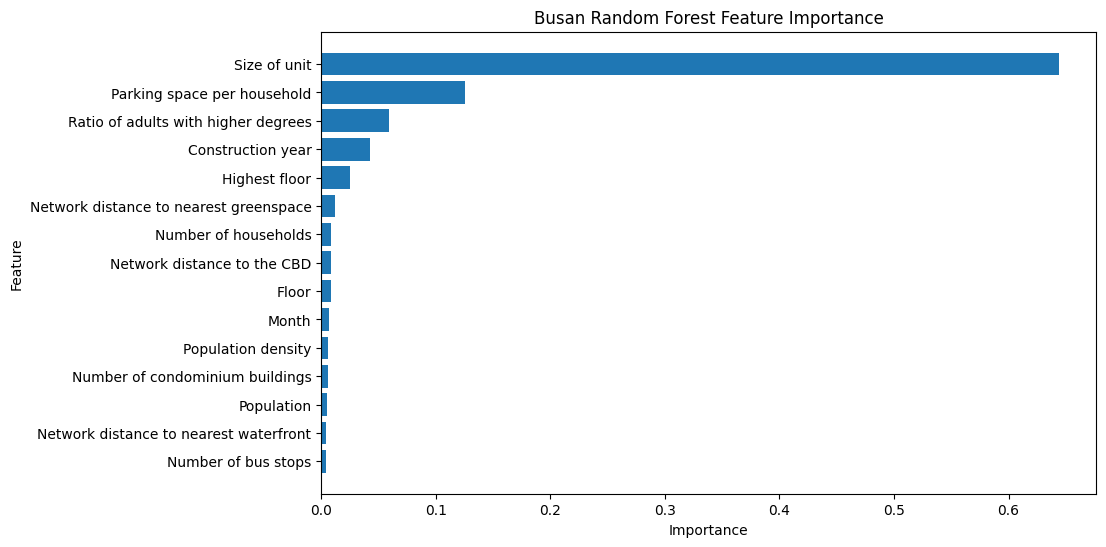

In [27]:
plt.figure(figsize=(10, 6))

top_features = feature_importance_busan.head(15)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Busan Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

Random Forest performed best for Busan and Daegu, while XGBoost performed best for Daejeon and Gwangju, with test R² around 0.97–0.99 and relatively low RMSE.
For the feature importance, Size of unit was by far the most influential variable (64.4%), followed by parking space per household (12.5%) and higher-degree population ratio (5.9%), suggesting that housing characteristics contributed most to the model's predictions.